In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("loan_dataset_20000.csv")

In [19]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [21]:
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

In [22]:
df = df[['age','education_level','annual_income','employment_status','loan_amount',"interest_rate",'installment','loan_paid_back']]

In [23]:
df

,age,education_level,annual_income,employment_status,loan_amount,interest_rate,installment,loan_paid_back
0,59,Master's,24240.19,Employed,17173.72,13.39,581.88,1
1,72,Bachelor's,20172.98,Employed,22663.89,17.81,573.17,1
2,49,High School,26181.80,Employed,3631.36,9.53,76.32,1
3,35,High School,11873.84,Employed,14939.23,7.99,468.07,1
4,63,Other,25326.44,Employed,16551.71,15.20,395.50,1
...,...,...,...,...,...,...,...,...
19995,39,Bachelor's,39640.08,Employed,16322.23,15.05,566.22,0
19996,66,Bachelor's,32062.90,Employed,16697.34,11.89,553.71,1
19997,65,Master's,18642.02,Student,23924.78,10.06,772.66,1
19998,35,Master's,22181.39,Retired,16920.13,16.06,595.36,1


In [24]:
df['employment_status'].unique()

array(['Employed', 'Unemployed', 'Self-employed', 'Student', 'Retired'],
      dtype=object)

<Axes: xlabel='employment_status', ylabel='Count'>

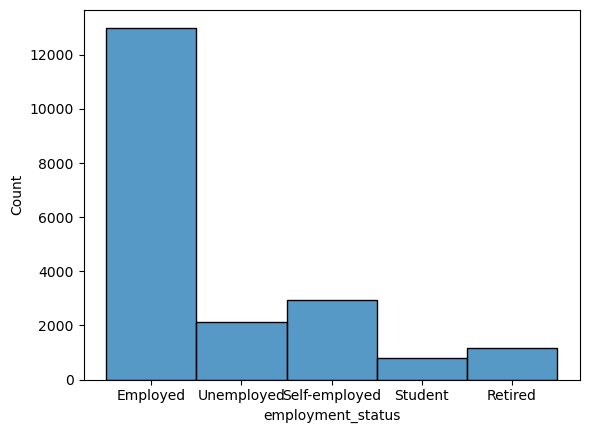

In [25]:
sns.histplot(x='employment_status',data=df)

In [26]:
bins = [0, 30, 50, np.inf]  # 0–30, 30–50, 50+
labels = ['Young_Adult', 'Adult', 'Old']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
df['age_group'].value_counts()

age_group
Old            9347
Adult          7473
Young_Adult    3180
Name: count, dtype: int64

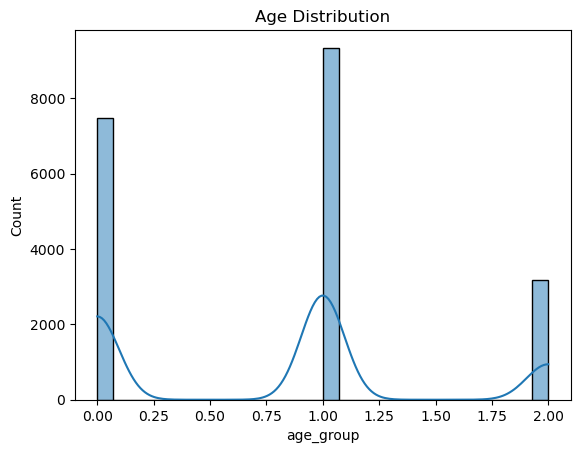

In [41]:
sns.histplot(df['age_group'], kde=True)
plt.title("Age Distribution")
plt.show()

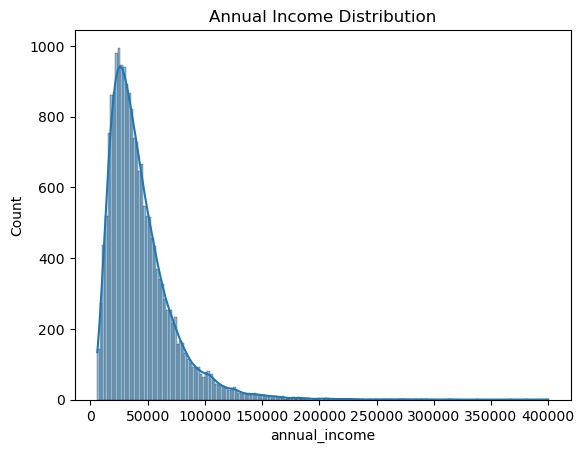

In [42]:
sns.histplot(df['annual_income'], kde=True)
plt.title("Annual Income Distribution")
plt.show()

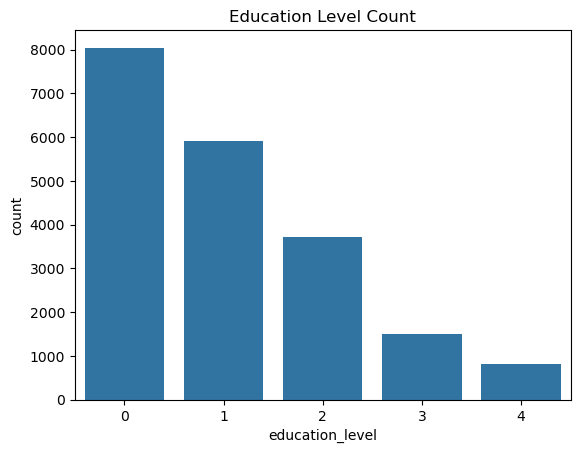

In [43]:
sns.countplot(x='education_level', data=df)
plt.title("Education Level Count")
plt.show()

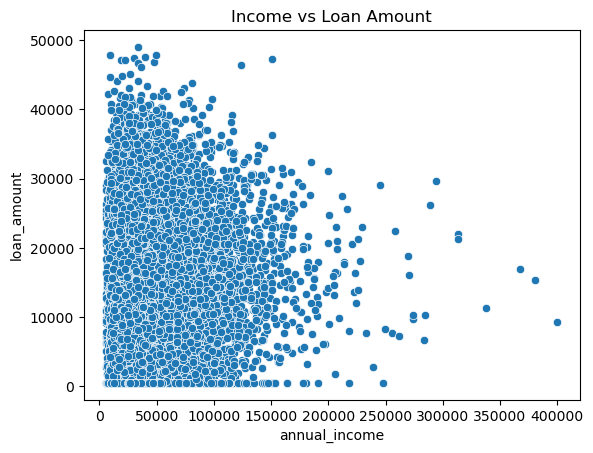

In [44]:
sns.scatterplot(x='annual_income', y='loan_amount', data=df)
plt.title("Income vs Loan Amount")
plt.show()

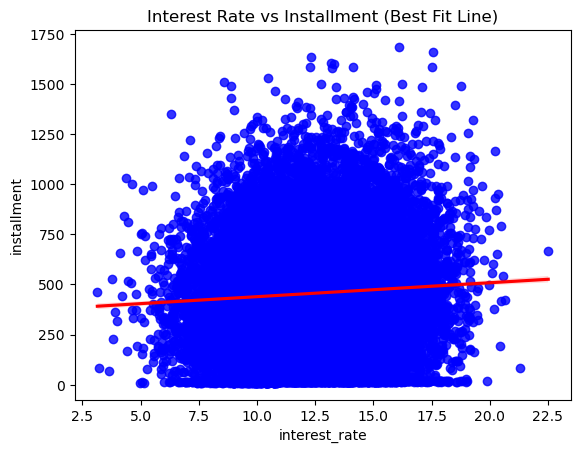

In [76]:
sns.regplot(x='interest_rate', y='installment', data=df,scatter_kws={'color':'blue'},line_kws={'color':'red'})

plt.title("Interest Rate vs Installment (Best Fit Line)")
plt.show()

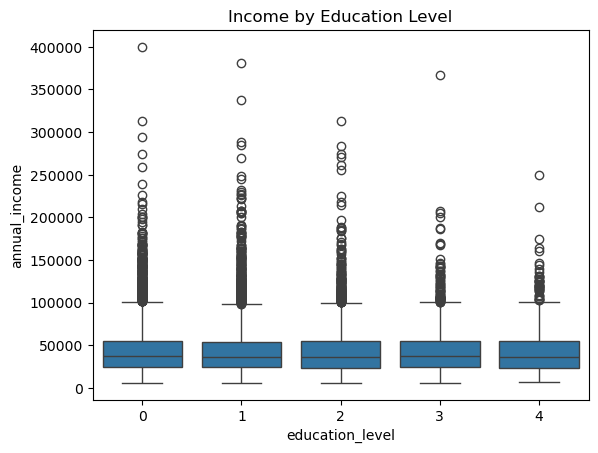

In [46]:
sns.boxplot(x='education_level', y='annual_income', data=df)
plt.title("Income by Education Level")
plt.show()

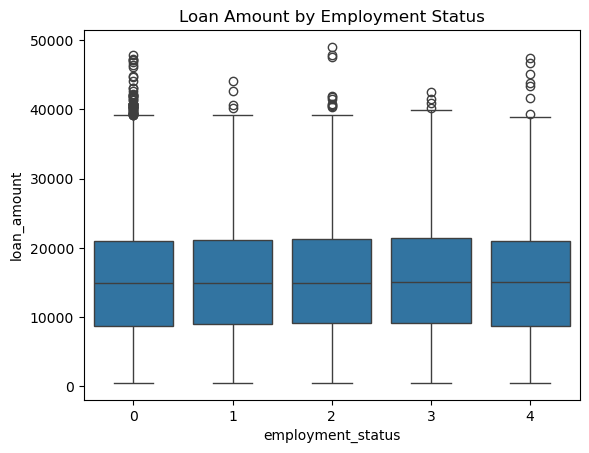

In [47]:
sns.boxplot(x='employment_status', y='loan_amount', data=df)
plt.title("Loan Amount by Employment Status")
plt.show()

In [59]:
df.describe()

,age,education_level,annual_income,employment_status,loan_amount,interest_rate,installment,loan_paid_back,age_group
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,1.055350,43549.637765,0.890850,15129.300909,12.400627,455.625794,0.799900,0.785350
std,15.829352,1.117519,28668.579671,1.375402,8605.405513,2.442729,274.622125,0.400085,0.697567
min,21.000000,0.000000,6000.000000,0.000000,500.000000,3.140000,9.430000,0.000000,0.000000
25%,35.000000,0.000000,24260.752500,0.000000,8852.695000,10.740000,253.910000,1.000000,0.000000
50%,48.000000,1.000000,36585.260000,0.000000,14946.170000,12.400000,435.595000,1.000000,1.000000
75%,62.000000,2.000000,54677.917500,2.000000,20998.867500,14.002500,633.595000,1.000000,1.000000
max,75.000000,4.000000,400000.000000,4.000000,49039.690000,22.510000,1685.400000,1.000000,2.000000


In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['education_level'] = le.fit_transform(df['education_level'])
df['employment_status'] = le.fit_transform(df['employment_status'])
df['age_group'] = le.fit_transform(df['age_group'])

In [32]:
X = df.drop('loan_paid_back', axis=1)
y = df['loan_paid_back']

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [62]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8625


In [63]:
from sklearn.metrics import precision_score
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.8762149799885649


In [64]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.7798120233157476


In [65]:
from sklearn.metrics import f1_score
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.9176646706586826


In [66]:
from sklearn.metrics import recall_score
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.9632306725329981


In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.47      0.58       818
           1       0.88      0.96      0.92      3182

    accuracy                           0.86      4000
   macro avg       0.82      0.72      0.75      4000
weighted avg       0.85      0.86      0.85      4000



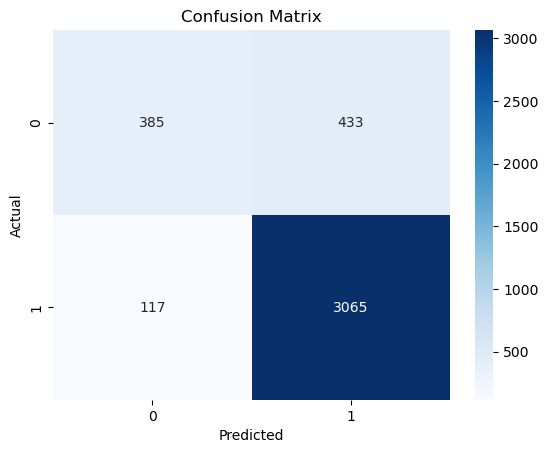

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred))

RF Accuracy: 0.87025


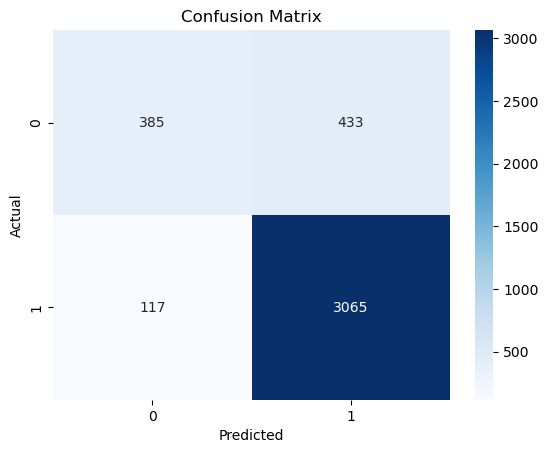

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.47      0.58       818
           1       0.88      0.96      0.92      3182

    accuracy                           0.86      4000
   macro avg       0.82      0.72      0.75      4000
weighted avg       0.85      0.86      0.85      4000



In [55]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print("XGB Accuracy:", accuracy_score(y_test, y_pred))

XGB Accuracy: 0.867


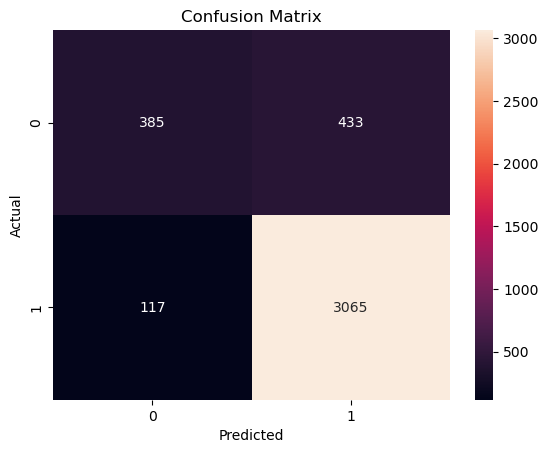

In [58]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()